# JARINGAN SARAF PENGENAL GAMBAR



**Convolutional Neural Network (CNN)** adalah jenis jaringan saraf tiruan yang dirancang khusus untuk mengatasi kelemahan jaringan saraf konvensional dalam pemrosesan gambar. CNN mengurangi kompleksitas dan *overfitting* dengan menggunakan koneksi sebagian (tidak sepenuhnya terhubung) dan berbagi bobot antar neuron. CNN juga mempertahankan informasi spasial dari gambar, yang hilang saat gambar diratakan pada jaringan biasa.

Ada beberapa kelemahan jaringan konvensional, terutama dalam pemrosesan atau pengidentifikasian objek pada gambar:
1. Setiap nilai piksel gambar ditangani oleh satu neuron di *input layer*. Semakin banyak piksel, semakin banyak neuron yang diperlukan. Pada gambar warna, terdapat tiga saluran (*channel* Red, Green, Blue/RGB) sehingga jumlah neuron *input layer* menjadi tiga kali lebih banyak.
2. Akibat jumlah variabel *input* yang sangat banyak, jumlah parameter jaringan menjadi tidak terkendali. Misalnya, untuk gambar skala abu-abu berukuran 280×360 piksel diperlukan 100.800 input neuron. Dengan 128 neuron pada *hidden layer* dan 10 neuron pada *output layer*, terdapat **12.902.400 parameter** jaringan yang harus dilatih! Ini membutuhkan waktu lama dan memperbesar kemungkinan *overfitting*.
3. Hilangnya informasi spasial ketika gambar diratakan (*flatten*). Struktur kedekatan antar-piksel yang mendefinisikan bentuk gambar menjadi hilang.

CNN menambahkan struktur khusus berupa lapisan-lapisan yang terhubung sebagian (*partially connected*) dengan mekanisme berbagi pakai bobot (*weight sharing*).

CNN muncul dari studi visual otak korteks dan telah digunakan sejak tahun 1980-an. Berkat peningkatan daya komputasi, jumlah *Training Set*, dan metode optimasi modern, CNN kini mencapai kinerja menyamai bahkan melebihi manusia pada tugas visual kompleks (pencarian gambar, mobil otonom, klasifikasi video). CNN juga berhasil dalam *Voice Recognition* dan *Natural Language Processing*.

**Berikut dua konsep dasar pada CNN:**
1. Piksel-piksel gambar yang berdekatan memiliki keterkaitan yang lebih kuat dibanding dengan piksel-piksel yang saling berjauhan.
2. Suatu objek dibangun secara hierarki. Ia terdiri dari objek-objek yang lebih kecil, yang dibangun oleh objek lain yang lebih kecil lagi, dan seterusnya.

---

## 11.1 Pemrosesan Piksel Gambar

Sebelum gambar dikirimkan ke jaringan, perlu dilakukan *pra-proses* (data *preprocessing*) agar mesin dapat dengan mudah memprosesnya dan meningkatkan performa algoritme.

Pada CNN, gambar didefinisikan dalam bentuk *array/tensor* 3 dimensi (3D), terdiri dari:
* Tinggi (*height*)
* Lebar (*width*)
* Kedalaman (*depth*) atau *channel*. (Skala abu-abu = 1 saluran, Warna RGB = 3 saluran).

**Notasi Ukuran:** $\text{tinggi} \times \text{lebar}$  
**Notasi Bentuk (Shape):** $\text{tinggi} \times \text{lebar} \times \text{kedalaman}$  
*(Misal: gambar warna dengan tinggi dan lebar 227 piksel memiliki shape $227 \times 227 \times 3$)*.

Setiap piksel RGB dikodekan dengan nilai $0$ hingga $255$. Berbeda dengan gambar warna, gambar skala abu-abu berisi satu representasi intensitas cahaya dengan rentang $[0, 255]$ (total 256 tingkat skala abu-abu). CNN bekerja lebih baik ketika nilai variabel input kecil, sehingga perlu diskalakan menggunakan normalisasi atau standardisasi.

### 11.1.1 Normalisasi
Normalisasi mengubah rentang nilai aktual (misal $[0, 255]$) menjadi rentang $[-1, 1]$ atau $[0, 1]$.

Untuk normalisasi ke rentang $[0, 1]$:
$$x'_{i} = \frac{x_{i} - \min_{i}}{\max_{i} - \min_{i}}$$

Untuk normalisasi ke rentang $[-1, 1]$:
$$x'_{i} = \frac{2 \times x_{i} - \min_{i} - \max_{i}}{\max_{i} - \min_{i}}$$

*Contoh:* Untuk dataset gambar skala abu-abu (min = 0, max = 255), piksel bernilai 100 akan menjadi:
* Normalisasi $[0, 1]$: $\frac{100}{255} = 0,39$
* Normalisasi $[-1, 1]$: $\frac{200 - 255}{255} = -0,22$

### 11.1.2 Standardisasi
Mekanisme ini menykalakan nilai *input* sehingga memiliki distribusi normal standar dengan nilai rata-rata $\mu = 0$ dan deviasi standar $\sigma = 1$ (seperti metode *Batchnorm*).

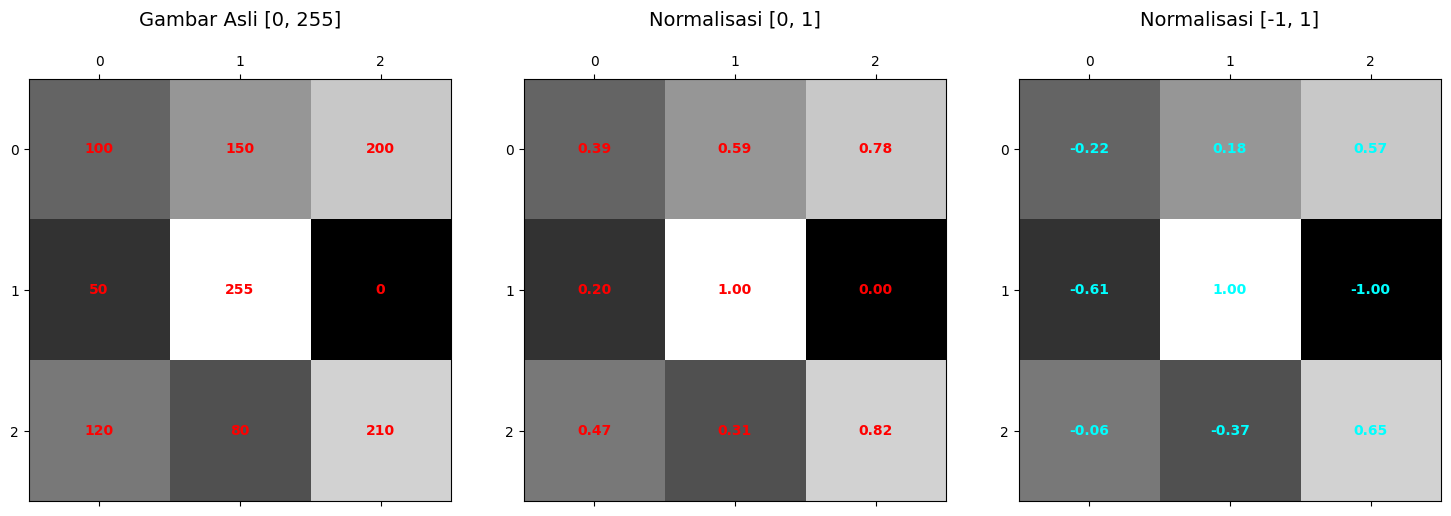

In [1]:
# --- KODE ILUSTRASI: NORMALISASI GAMBAR ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulasi gambar skala abu-abu 3x3 piksel
gambar_asli = np.array([
    [100, 150, 200],
    [50,  255, 0],
    [120, 80,  210]
], dtype=np.float32)

min_val, max_val = 0, 255

# 2. Proses Normalisasi
norm_01 = (gambar_asli - min_val) / (max_val - min_val)
norm_11 = (2 * gambar_asli - min_val - max_val) / (max_val - min_val)

# 3. Visualisasi dengan Matplotlib
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Gambar Asli
cax0 = axes[0].matshow(gambar_asli, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Gambar Asli [0, 255]\n', fontsize=14)
for (i, j), z in np.ndenumerate(gambar_asli):
    axes[0].text(j, i, f'{z:.0f}', ha='center', va='center', color='red', weight='bold')

# Plot Normalisasi [0, 1]
cax1 = axes[1].matshow(norm_01, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Normalisasi [0, 1]\n', fontsize=14)
for (i, j), z in np.ndenumerate(norm_01):
    axes[1].text(j, i, f'{z:.2f}', ha='center', va='center', color='red', weight='bold')

# Plot Normalisasi [-1, 1]
cax2 = axes[2].matshow(norm_11, cmap='gray', vmin=-1, vmax=1)
axes[2].set_title('Normalisasi [-1, 1]\n', fontsize=14)
for (i, j), z in np.ndenumerate(norm_11):
    axes[2].text(j, i, f'{z:.2f}', ha='center', va='center', color='cyan', weight='bold')

plt.tight_layout()
plt.show()

## 11.2 Lapisan CNN dan Operasi Convolution

Setelah *preprocessing*, data masuk ke **Convolution Layer**, yakni lapisan berisi sekumpulan *filter* dan *feature map*. *Feature map* terdiri dari neuron-neuron yang menyimpan hasil penerapan *filter* pada gambar.

### 11.2.1 Jaringan Neuron Tiruan (Filter/Kernel)
**Convolution Filter** atau **Kernel** (umumnya $3 \times 3$ atau $5 \times 5$ piksel) menangkap keterkaitan piksel berdekatan. Setiap piksel pada filter memiliki bobot yang dapat dilatih dengan *Backpropagation*. Area gambar yang ditempeli filter disebut **Local Receptive Field**.


Jika kita ingin mendeteksi huruf "X", kita membuat filter dengan pola serupa. Namun, jika huruf "X" terdistorsi (berubah letak, ukuran, atau rotasi), satu filter besar akan gagal. Alih-alih satu filter besar, CNN menggunakan **sekumpulan filter-filter kecil** (hierarki) untuk membandingkan kecocokan fitur, membuat CNN jauh lebih *robust*.


Pola garis diagonal "X" dan "Y" dideteksi Filter 1 dan Filter 2, garis vertikal "Y" dideteksi Filter 3. Secara hierarki, filter objek "rumah" dapat menggunakan filter "pintu" dan "jendela", di mana filter "pintu" menggunakan filter "garis vertikal/horizontal".

### 11.2.2 Operasi Convolution

Pengaplikasian filter pada gambar (misal filter $3 \times 3$ pada gambar $7 \times 7$) dimulai dari sudut kiri atas dengan memosisikan titik tengah filter pada **piksel target**. 


**Langkah Operasi Convolution:**
1. Kalikan masing-masing piksel gambar yang terkena *local receptive field* dengan bobot filter secara *element-wise*.
2. Jumlahkan hasil perkalian: $(1 \times 1) + (-1 \times -1) + \dots + (1 \times 1) = 9$.
3. Normalisasi (opsional) dibagi jumlah piksel filter: $\frac{9}{9} = 1$.
4. Tambahkan nilai bias $b$. Jika $b = 0$, maka $z = 1 + 0 = 1$.
5. Hitung nilai fungsi aktivasi. Jika menggunakan ReLU: $a(z) = \max(0, z) = 1$.
6. Hasil ini diletakkan pada *feature map*. Filter digerakkan ke kanan dan proses diulang.

Neuron-neuron pada *feature map* memiliki **nilai bobot yang sama** (berbagi pakai / *weight sharing*).

Untuk gambar warna (3 saluran RGB):
* Jumlah filter harus sama dengan jumlah saluran (Kedalaman = 3).
* Hasil operasi perkalian filter pada tiga saluran dijumlahkan dan ditambah bias untuk membentuk **satu nilai** aktivasi neuron pada *feature map*.

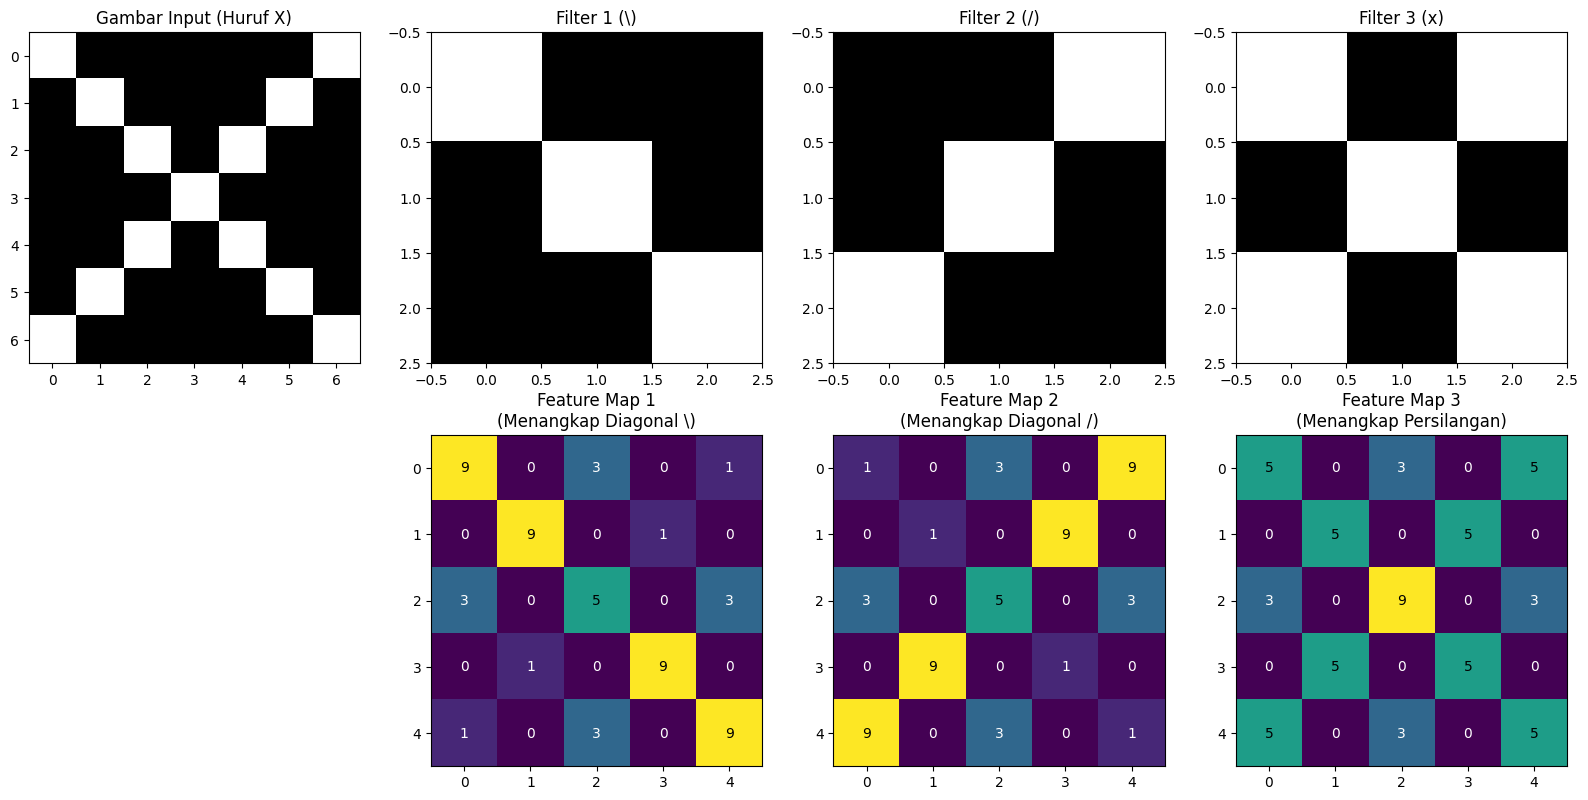

In [2]:
# --- KODE ILUSTRASI: KONVOLUSI HURUF X DENGAN 3 FILTER ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# 1. Mendefinisikan Gambar Input berbentuk Huruf "X" (7x7)
# Menggunakan 1 untuk warna putih (fitur) dan -1 untuk background hitam
img_x = np.array([
    [ 1, -1, -1, -1, -1, -1,  1],
    [-1,  1, -1, -1, -1,  1, -1],
    [-1, -1,  1, -1,  1, -1, -1],
    [-1, -1, -1,  1, -1, -1, -1],
    [-1, -1,  1, -1,  1, -1, -1],
    [-1,  1, -1, -1, -1,  1, -1],
    [ 1, -1, -1, -1, -1, -1,  1]
])

# 2. Mendefinisikan 3 Filter (3x3)
# Filter 1: Garis Diagonal Kiri ke Kanan Bawah (\)
filter1 = np.array([[ 1, -1, -1],
                    [-1,  1, -1],
                    [-1, -1,  1]])

# Filter 2: Garis Diagonal Kanan ke Kiri Bawah (/)
filter2 = np.array([[-1, -1,  1],
                    [-1,  1, -1],
                    [ 1, -1, -1]])

# Filter 3: Bentuk silang kecil (x)
filter3 = np.array([[ 1, -1,  1],
                    [-1,  1, -1],
                    [ 1, -1,  1]])

# 3. Operasi Convolution (menggunakan scipy convolve2d dengan mode 'valid' tanpa padding ekstra)
# Dan menerapkan fungsi aktivasi ReLU: max(0, x)
def relu(x):
    return np.maximum(0, x)

# Catatan: convolve2d secara default membalik filter (flip), kita butuh korelasi silang,
# jadi kita putar filternya 180 derajat (atau menggunakan argumen yang tepat).
# Untuk kemudahan edukasi, kita gunakan fungsi korelasi spasial langsung:
feature_map_1 = relu(convolve2d(img_x, filter1[::-1, ::-1], mode='valid'))
feature_map_2 = relu(convolve2d(img_x, filter2[::-1, ::-1], mode='valid'))
feature_map_3 = relu(convolve2d(img_x, filter3[::-1, ::-1], mode='valid'))

# 4. Visualisasi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Baris Atas: Gambar Asli dan 3 Filter
axes[0,0].imshow(img_x, cmap='gray')
axes[0,0].set_title('Gambar Input (Huruf X)')
axes[0,1].imshow(filter1, cmap='gray')
axes[0,1].set_title('Filter 1 (\\)')
axes[0,2].imshow(filter2, cmap='gray')
axes[0,2].set_title('Filter 2 (/)')
axes[0,3].imshow(filter3, cmap='gray')
axes[0,3].set_title('Filter 3 (x)')

# Baris Bawah: Hasil Feature Map setelah ReLU
axes[1,0].axis('off') # Kosongkan bagian bawah gambar asli
cax1 = axes[1,1].imshow(feature_map_1, cmap='viridis')
axes[1,1].set_title('Feature Map 1\n(Menangkap Diagonal \\)')
cax2 = axes[1,2].imshow(feature_map_2, cmap='viridis')
axes[1,2].set_title('Feature Map 2\n(Menangkap Diagonal /)')
cax3 = axes[1,3].imshow(feature_map_3, cmap='viridis')
axes[1,3].set_title('Feature Map 3\n(Menangkap Persilangan)')

# Tambahkan nilai ke Feature Map untuk memperjelas hasil kalkulasi
for ax, fmap in zip([axes[1,1], axes[1,2], axes[1,3]], [feature_map_1, feature_map_2, feature_map_3]):
    for (i, j), z in np.ndenumerate(fmap):
        ax.text(j, i, f'{z:.0f}', ha='center', va='center', color='white' if z<4 else 'black')

plt.tight_layout()
plt.show()

### 11.2.3 Mekanisme Padding, Pooling & Stride

**Padding:** Karena piksel sisi gambar tidak bisa dijadikan piksel target, *feature map* akan mengecil. Untuk menyamakannya, ditambahkan *padding* (piksel *dummy*). Jika gambar dinormalisasi $[0, 1]$, digunakan nilai 0 (*zero padding*). 


**Downsampling / Pooling:** *Feature map* sangat sensitif terhadap letak objek. Untuk mendapat sifat **Local Translation Invariance** (kebal terhadap perbedaan posisi fitur), dilakukan *downsampling*.
* **Pooling:** Meringkas keberadaan fitur sekaligus mengurangi jumlah parameter/noise, mencegah *overfitting*.
* **Average Pooling:** Merangkum rata-rata nilai aktivasi fitur.
* **Max Pooling:** Mengambil nilai aktivasi fitur paling dominan/terbesar. Area *pooling* umumnya $2 \times 2$. Memotong panjang dan lebar kira-kira setengahnya.

**Same Pooling vs Valid Pooling:**
* *Same pooling:* Menambahkan *padding* agar semua piksel sisa masuk penghitungan.
* *Valid pooling:* Tanpa *padding*, piksel sisa diabaikan.

---
**Studi Kasus: Pengenalan Gambar Bentuk Huruf X dan Y**
Mendeteksi huruf "X", huruf "X" terdistorsi, dan "Y" dengan 3 filter.
1. Terapkan 3 filter pada piksel gambar secara paralel.
2. Hasilkan 3 *feature map* terpisah.
3. Lakukan *same max pooling* menghasilkan 3 *pooled feature map* berukuran lebih kecil, namun tetap mempertahankan pola kedekatan visual aslinya jika ditumpuk transparan.

**Stride:**
Langkah pergerakan filter, dinotasikan $\text{stride} = (h, v)$. Jika *stride* > 1, ini juga bertindak sebagai mekanisme *downsampling* (mengurangi dimensi), tetapi hasilnya **tidak identik** dengan *pooling*. Waktu komputasi dengan *stride* umumnya lebih cepat dari *pooling*.


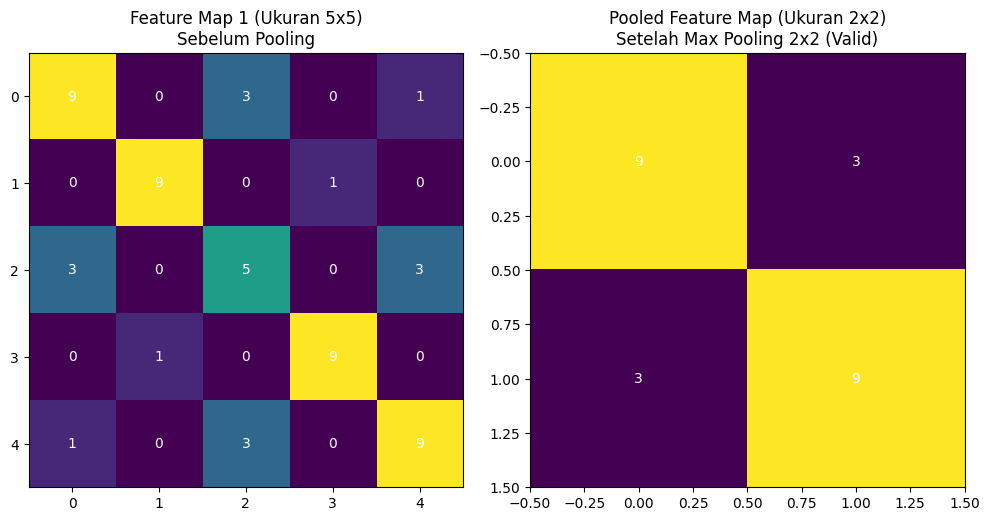

In [3]:
# --- KODE ILUSTRASI: MAX POOLING PADA FEATURE MAP ---
# Kita gunakan feature_map_1 (ukuran 5x5) dari operasi sebelumnya
# dan menerapkan MaxPooling 2x2 dengan Stride 2

def max_pooling_2x2(feature_map):
    # Mengambil dimensi output (Valid Pooling)
    out_h = feature_map.shape[0] // 2
    out_w = feature_map.shape[1] // 2
    pooled = np.zeros((out_h, out_w))
    
    for i in range(out_h):
        for j in range(out_w):
            # Mengambil area 2x2
            patch = feature_map[i*2 : i*2+2, j*2 : j*2+2]
            # Mengambil nilai maksimum
            pooled[i, j] = np.max(patch)
            
    return pooled

pooled_map = max_pooling_2x2(feature_map_1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot Feature Map Asli (5x5)
axes[0].imshow(feature_map_1, cmap='viridis')
axes[0].set_title('Feature Map 1 (Ukuran 5x5)\nSebelum Pooling', fontsize=12)
for (i, j), z in np.ndenumerate(feature_map_1):
    axes[0].text(j, i, f'{z:.0f}', ha='center', va='center', color='white')

# Plot Pooled Feature Map (2x2) -> karena 5//2 = 2
axes[1].imshow(pooled_map, cmap='viridis')
axes[1].set_title('Pooled Feature Map (Ukuran 2x2)\nSetelah Max Pooling 2x2 (Valid)', fontsize=12)
for (i, j), z in np.ndenumerate(pooled_map):
    axes[1].text(j, i, f'{z:.0f}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

## 11.5 Arsitektur CNN

CNN secara umum terdiri dari tiga jenis layer: **Convolution Layer**, **Pooling Layer**, dan **Fully Connected (FC) Layer / DNN**.

Bagian awal mempelajari fitur tingkat rendah (garis), sedangkan bagian lebih dalam mempelajari fitur tingkat tinggi (objek tertentu). Diakhiri dengan lapisan DNN yang diratakan (*flatten*) untuk klasifikasi objek.

### 11.5.1 LeNet-5
Dibuat oleh Yann LeCun (1998) untuk mengenali angka tulisan tangan dataset **MNIST** (60.000 gambar, abu-abu $28 \times 28 \times 1$). Populer di lembaga keuangan/bank. Filter dibuat otomatis oleh CNN.
* Arsitektur: 2 *Convolution Layer*, 2 *Average-Pooling Layer*, diakhiri FC layer (DNN).
* Total sekitar 60.000 parameter jaringan.

### 11.5.2 AlexNet
Ditemukan Alex Krizhevsky (2012) untuk dataset **ImageNet** (14 juta gambar, 22 ribu label). Model dilatih menggunakan dua GPU. Mengubah paradigma *Computer Vision*.
* 8 Layer: 5 *Convolution layer* (dengan *max pooling*) dan 3 *FC layer*.
* Menggunakan ReLU, **Dropout**, dan **Data Augmentation** (*crop*, *flip*, ubah warna RGB) untuk mengurangi *overfitting*.

### 11.5.3 VGG
Diciptakan *Visual Geometry Group* (VGG) Oxford. Fokus utama adalah **kedalaman jaringan**.
* Menerima input RGB $224 \times 224 \times 3$.
* Filter *convolution* sangat kecil ($3 \times 3$) tanpa *stride* dan menggunakan aktivasi ReLU.
* Terdapat 5 *max pooling layer* ($2 \times 2$, $\text{stride} = (2,2)$) yang mengecilkan dimensi $224 \to 112 \to 56 \to 28 \to 14 \to 7$.
* Tiga *FC layer* (4096, 4096, dan 1000 neuron *Softmax*).

---

### Studi Kasus: Visualisasi Feature Map pada CNN
Mendeteksi gambar gedung dengan arsitektur VGG-16.

* **Layer Pertama (64 feature map, $224 \times 224$):** Menangkap garis pembatas objek (*edge*) tebal, garis vertikal, dan horizontal.
* **Layer Keempat (128 feature map, $112 \times 112$):** Bentuk gedung sudah dapat ditangkap utuh dengan memadukan karakteristik dari *feature map* di lapisan awal.

---

### Studi Kasus: Identifikasi Gambar Angka Tulisan Tangan
Membandingkan LeNet-5 dengan DNN Adam+Dropout (Batch 128) menggunakan dataset MNIST.
* Akurasi LeNet-5 senantiasa melampaui DNN sejak dari *epochs* awal.
* Waktu eksekusi pembelajaran bobot LeNet-5 **sepuluh kali lebih besar** dibanding DNN.
* Namun, waktu pemanfaatan model (inferensi) relatif sama cepatnya. Pemrosesan bisa dipercepat drastis menggunakan pemrosesan paralel inti (cores) pada **GPU**.


In [4]:
# --- RANGKUMAN KODE ARSITEKTUR CNN: LENET-5 DAN VGG-STYLE BLOCK ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense

# 1. Rangkuman Arsitektur mirip LeNet-5
model_lenet = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='tanh', padding='same', input_shape=(28, 28, 1)),
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
    Conv2D(16, kernel_size=(5, 5), activation='tanh', padding='valid'),
    AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),
    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

print("=== Arsitektur LeNet-5 ===")
model_lenet.summary()

# 2. Ilustrasi Pola Blok VGG (Filter 3x3, Max Pooling 2x2 Stride 2)
model_vgg_block = Sequential([
    # Input 224x224x3
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), strides=(2, 2)), # Mengurangi ukuran menjadi 112x112
    
    Flatten(),
    Dense(1000, activation='softmax')
])

print("\n=== Arsitektur Dasar Blok VGG ===")
model_vgg_block.summary()

2026-03-01 17:08:28.836992: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 17:08:28.844125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-01 17:08:29.086199: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 17:08:30.000845: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

=== Arsitektur LeNet-5 ===


/home/khai/LLMEng2/AITF/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1772359710.541033    6965 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772359710.550126    6965 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 802816)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │   802,817,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802,855,720 (2.99 GB)

 Trainable params: 802,855,720 (2.99 GB)

 Non-trainable params: 0 (0.00 B)